# How to train your own word vector embeddings with Keras

Many tasks require embeddings or domain-specific vocabulary that pre-trained models based on a generic corpus may not represent well or at all. Standard word2vec models are not able to assign vectors to out-of-vocabulary words and instead use a default vector that reduces their predictive value.

E.g., when working with industry-specific documents, the vocabulary or its usage may change over time as new technologies or products emerge. As a result, the embeddings need to evolve as well. In addition, corporate earnings releases use nuanced language not fully reflected in Glove vectors pre-trained on Wikipedia articles.

We will illustrate the word2vec architecture using the keras library that we will introduce in more detail in the next chapter and the more performant gensim adaptation of the code provided by the word2vec authors. 

To illustrate the word2vec network architecture, we use the Financial News data that we first introduced in chapter 14 on Topic Modeling. 

## Imports

If you have not yet installed `TensorFlow 2`, uncomment and run one of the following, the first if you have a GPU and the second otherwise. Alternatively, run this notebook using the environment `ml4t-dl`.

In [1]:
# !conda install -n ml4t tensorflow-gpu -y

In [2]:
#!conda install -n ml4t tensorflow -y

In [1]:
%matplotlib inline

from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Dot, Embedding
from tensorflow.keras.preprocessing.sequence import skipgrams, make_sampling_table
from tensorflow.keras.callbacks import Callback, TensorBoard

import matplotlib.pyplot as plt
import seaborn as sns

print("Import done!")

Import done!


In [2]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print('Using GPU')
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print('Using CPU')

Using CPU


### Settings

In [5]:
sns.set_style('white')
np.random.seed(42)

### Paths

In [17]:
results_path = Path('C:/','data','01-algo-trading','results', 'financial_news')
print(results_path)

C:\data\01-algo-trading\results\financial_news


In [18]:
analogy_path = Path('data', 'analogies-en.txt')
print(analogy_path)

data\analogies-en.txt


In [19]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f'{h:02.0f}:{m:02.0f}:{s:02.0f}'

## `word2vec` - skipgram Architecture using Keras

The **skip-gram** model learns word embeddings by training a shallow neural network
to predict the surrounding *context* words given a *target* word.
For a target word $w_t$ and a context window of size $k$, the objective is:

$$
\max \sum_{-k \leq j \leq k,\, j \neq 0} \log P(w_{t+j} \mid w_t)
$$

Each word is represented by two vectors: an **input embedding** $\mathbf{v}_w$
(used when the word appears as a target) and an **output embedding** $\mathbf{u}_w$
(used when it appears as context). The probability of a context word $c$ given
target $w$ is modelled via a dot product followed by a softmax:

$$
P(c \mid w) = \frac{\exp(\mathbf{u}_c^\top \mathbf{v}_w)}
               {\sum_{w' \in V} \exp(\mathbf{u}_{w'}^\top \mathbf{v}_w)}
$$

### Noise Contrastive Estimation

Computing the full softmax over the vocabulary $V$ is prohibitively expensive
for large corpora. We instead use **Noise Contrastive Estimation (NCE)**: for each
real (target, context) pair, we sample $k$ *noise* pairs drawn from the unigram
distribution and train a binary classifier to distinguish real from noise:

$$
\mathcal{L} = \log \sigma(\mathbf{u}_c^\top \mathbf{v}_w)
            + \sum_{i=1}^{k} \mathbb{E}_{\tilde{w} \sim P_n}
              \left[ \log \sigma(-\mathbf{u}_{\tilde{w}}^\top \mathbf{v}_w) \right]
$$

This reduces the per-step cost from $\mathcal{O}(|V|)$ to $\mathcal{O}(k)$,
making training on large corpora tractable.

### Keras Implementation

We implement the skip-gram model using the **Keras functional API**, which lets us
make the network structure explicit. The key components are:

| Component | Description |
|---|---|
| `Input` (×2) | Two scalar integer inputs: target word ID and context word ID |
| `Embedding` | A single **shared** layer of shape $(V \times d)$, where $d = 300$ |
| `Dot` | Dot product of the two embedding vectors |
| `Dense(1, sigmoid)` | Binary output: real pair (1) vs. noise pair (0) |

Because both the target and the context pass through the **same** `Embedding` layer,
the model learns a single set of word vectors that captures both roles simultaneously.
A separate *validation model* (same weights, cosine similarity) is used at each epoch
to retrieve nearest neighbours and evaluate analogy accuracy without affecting training.

### Settings

In [20]:
LANGUAGE = 'en'
SAMPLE_SIZE=.5              # portion of sentences to use for model
NGRAMS = 3                  # Longest ngram in text
MIN_FREQ = 10

In [21]:
SAMPLING_FACTOR = 1e-4
WINDOW_SIZE = 3
EMBEDDING_SIZE = 300
EPOCHS = 1
BATCH_SIZE = 2500

In [22]:
# Set up validation
VALID_SET = 10      # Random set of words to get nearest neighbors for
VALID_WINDOW = 150  # Most frequent words to draw validation set from
NN = 10             # Number of nearest neighbors for evaluation

valid_examples = np.random.choice(VALID_WINDOW, size=VALID_SET, replace=False)

In [23]:
FILE_NAME = f'articles_{NGRAMS}_grams.txt'
file_path = results_path / FILE_NAME

In [24]:
tb_path = results_path / 'tensorboard'
if not tb_path.exists():
    tb_path.mkdir(parents=True, exist_ok=True)

### Build Data Set

Before the model can be trained, the raw text corpus must be transformed into
numerical tensors that Keras can consume. This section covers four sequential
steps: vocabulary construction, analogy mapping, subsampling probability
generation, and skip-gram pair creation.

---

#### Step 1 — Tokens to ID

The corpus stored in `articles_3_grams.txt` is a plain-text file where each
line is one sentence. Loading and cleaning proceeds as follows.

**1. Filter by sentence length.**
Very long sentences (more than `max_length = 50` tokens) are discarded. They
are typically boilerplate or malformed lines that would generate a
disproportionate number of training pairs and slow down the pipeline.

**2. Random sentence sampling.**
Only 50 % of the remaining sentences are sampled (without replacement) before
word counting. This is a deliberate trade-off: it reduces memory pressure and
pair-generation time at the cost of a smaller effective corpus — acceptable
for a pedagogical single-epoch run.

**3. Frequency filtering.**
Token counts are computed with `collections.Counter`. Only tokens appearing at
least `MIN_FREQ` times are retained. Rare words carry little statistical signal
and would waste embedding-table capacity.

**4. Integer encoding.**
The retained tokens are assigned consecutive integer IDs starting from 1.
ID `0` is reserved for the special `UNK` token, which replaces any word that
did not pass the frequency threshold. Two complementary dictionaries are built:

| Dictionary | Maps |
|---|---|
| `id_to_token` | integer → word string |
| `token_to_id` | word string → integer |

The full word list is then converted to a flat integer sequence `data`, where
each element is either the word's ID or `0` (UNK). This sequence is the direct
input to the skip-gram pair generator.

Finally, the token metadata is exported to `meta.tsv` — a tab-separated file
consumed by the TensorBoard Embedding Projector for interactive visualisation.

---

#### Step 2 — Analogies to ID

The Google word-analogy benchmark (`analogies-en.txt`) is used to evaluate
embedding quality during training. Each analogy takes the form:

$$
\mathbf{v}_b - \mathbf{v}_a + \mathbf{v}_c \approx \mathbf{v}_d
$$

*Example:* `Athens Greece Baghdad Iraq` encodes the relation
*"Athens is to Greece as Baghdad is to Iraq"*.

The file mixes **category header rows** (prefixed with `:`) and
**analogy rows** (four whitespace-separated words). The function
`get_analogies()` filters out headers and returns a `DataFrame` with columns
`a, b, c, d`. Each word is then mapped to its integer ID via `token_to_id`;
analogies containing at least one out-of-vocabulary word are automatically
excluded during evaluation, since the model has no vector for them.

The fraction of analogies that survive the vocabulary filter is printed as a
quick diagnostic of how well the financial corpus covers the benchmark.

---

#### Step 3 — Generate Sampling Probabilities

Training on raw token frequencies would cause the model to be dominated by
very common words such as *the*, *said*, or *company*, which appear in almost
every context and provide little discriminative signal.

Word2Vec addresses this with **subsampling**: each word $w$ is included in
training with probability

$$
P(w) = \min\!\left(1,\;
       \frac{\sqrt{\dfrac{f(w)}{t}}}{{\dfrac{f(w)}{t}}}\right)
     = \min\!\left(1, \sqrt{\frac{t}{f(w)}}\right)
$$

where $f(w)$ is the word's relative frequency and $t$ is the
`SAMPLING_FACTOR` threshold. The Keras utility `make_sampling_table()`
computes a lookup array where `sampling_table[i]` gives the retention
probability of the $i$-th most frequent word.

The effect is visualised for several values of `sampling_factor`: a very
small factor aggressively suppresses common words (the curve drops steeply),
while a large factor leaves the distribution nearly uniform. The chosen
`SAMPLING_FACTOR` is passed to `skipgrams()` in the next step.

---

#### Step 4 — Generate Target–Context Pairs

With the integer sequence `data` and the sampling table in hand, Keras's
`skipgrams()` function generates all training examples in one call:

```python
pairs, labels = skipgrams(
    sequence         = data,
    vocabulary_size  = vocab_size,
    window_size      = WINDOW_SIZE,
    sampling_table   = sampling_table,
    negative_samples = 1.0,
    shuffle          = True
)
```

For each target word at position $t$, every word within distance
`WINDOW_SIZE` becomes a **positive** context (label `1`). An equal number of
**negative** pairs (label `0`) is generated by replacing the context word with
a random token drawn from the vocabulary — this is the noise distribution
required by NCE loss.

The result is split into three arrays:

| Array | Content |
|---|---|
| `target_word` | integer IDs of the target words |
| `context_word` | integer IDs of the context (real or noise) words |
| `labels` | `1` = real pair, `0` = noise pair |

The balanced `1:1` ratio of positive to negative pairs is confirmed by
inspecting `pd.Series(labels).value_counts()`.

**Persistence to HDF5.**
Generating the pairs is the most time-consuming step. The three arrays are
written to `data.h5` via `pd.HDFStore` so that subsequent runs (e.g., for
hyperparameter tuning) can reload them instantly without regeneration.

#### Tokens to ID

1. Extract the top *n* most common words to learn embeddings
2. Index these *n* words with unique integers
3. Create an `{index: word}` dictionary
4. Replace the *n* words with their index, and a dummy value `UNK` elsewhere

In [27]:
# Read the sentence file using UTF-8 encoding.
# This avoids Windows default cp1252 decoding errors.
sentences = file_path.read_text(encoding='utf-8').splitlines()
# Count the number of sentences
n = len(sentences)
n

2956311

In [28]:
max_length = 50

In [29]:
sentences = [s for s in sentences if len(s.split()) <= max_length]

In [30]:
print(f'Removed {n-len(sentences):,.0f} sentences containing more than {max_length} tokens')

Removed 59,554 sentences containing more than 50 tokens


In [31]:
words = ' '.join(np.random.choice(sentences, size=int(.5*len(sentences)), replace=False)).split()

In [32]:
# Count how many times each word appears in the list `words`.
# Counter(words) creates a dictionary-like object where:
#   - the keys are tokens/words
#   - the values are their frequencies
#
# .most_common() returns a list of tuples sorted by frequency in descending order.
# Each tuple has the form:
#   (token, count)
#
# The list comprehension keeps only those tokens whose frequency is at least MIN_FREQ.
# Therefore, rare tokens are discarded from the vocabulary.
token_counts = [
    t
    for t in Counter(words).most_common()
    if t[1] >= MIN_FREQ
]

# Separate the list of (token, count) tuples into two parallel sequences:
#   tokens -> the words kept in the vocabulary
#   counts -> their corresponding frequencies
#
# Example:
#   token_counts = [('the', 120), ('market', 45), ('risk', 30)]
#
# Then:
#   tokens = ('the', 'market', 'risk')
#   counts = (120, 45, 30)
tokens, counts = list(zip(*token_counts))

# Create a dictionary that maps integer IDs to tokens.
#
# pd.Series(tokens, index=range(1, len(tokens) + 1)) creates a pandas Series
# where:
#   - the index starts from 1
#   - each index corresponds to one token
#
# Example:
#   1 -> 'the'
#   2 -> 'market'
#   3 -> 'risk'
#
# Starting from 1 is intentional because ID 0 will be reserved for unknown words.
id_to_token = pd.Series(
    tokens,
    index=range(1, len(tokens) + 1)
).to_dict()

# Add a special token for unknown words.
#
# The token 'UNK' is assigned ID 0.
# This will be used for all words that are not included in the vocabulary,
# for example because their frequency was lower than MIN_FREQ.
id_to_token.update({0: 'UNK'})

# Create the reverse dictionary: token -> integer ID.
#
# id_to_token maps:
#   ID -> token
#
# token_to_id maps:
#   token -> ID
#
# Example:
#   id_to_token = {0: 'UNK', 1: 'the', 2: 'market'}
#   token_to_id = {'UNK': 0, 'the': 1, 'market': 2}
#
# This reverse mapping is needed to transform raw text into numerical sequences.
token_to_id = {
    t: i
    for i, t in id_to_token.items()
}

# Convert the original list of words into a list of integer IDs.
#
# For each word in `words`, token_to_id.get(word, 0) does the following:
#   - if the word exists in the vocabulary, return its ID
#   - otherwise, return 0, which corresponds to 'UNK'
#
# The result is a numerical representation of the original text.
#
# Example:
#   words = ['the', 'unknown_word', 'market']
#   token_to_id = {'UNK': 0, 'the': 1, 'market': 2}
#
# Then:
#   data = [1, 0, 2]
data = [
    token_to_id.get(word, 0)
    for word in words
]

In [33]:
vocab_size = len(token_to_id)

In [34]:
vocab_size

60822

In [35]:
s = pd.Series(data).value_counts().reset_index()
s.columns = ['id', 'count']
s['token'] = s.id.map(id_to_token)

In [36]:
s.sort_values('count', ascending=False).head(10)

,id,count,token
0,0,412213,UNK
1,1,173215,company
2,2,171787,million
3,3,149490,said
4,4,119867,year
5,5,109004,quarter
6,6,83097,financial
7,7,75877,percent
8,8,75407,net
9,9,72647,new


In [37]:
s['count'].sum()

18003695

In [38]:
s.sort_values('id').token.dropna().to_csv(tb_path / 'meta.tsv', index=False)

#### Analogies to ID

In [41]:
def get_analogies():
    """
    Read the analogy file and return only the analogy rows.

    The analogy file contains two kinds of rows:
    - category rows, starting with ':'
    - analogy rows, containing four words: a b c d

    Returns
    -------
    analogies : pandas.DataFrame
        A dataframe with four columns: a, b, c, d.
    """

    # Read the file as a one-column DataFrame,
    # then explicitly select the column as a Series.
    # This replaces the old pandas argument squeeze=True.
    lines = pd.read_csv(
        analogy_path,
        header=None,
        names=["line"]
    )["line"]

    # Remove possible leading/trailing spaces
    lines = lines.str.strip()

    # Identify category rows.
    # Category rows start with ':'.
    is_category = lines.str.startswith(":", na=False)

    # Keep only analogy rows
    analogy_lines = lines[~is_category]

    # Split each analogy row into four words
    analogies = analogy_lines.str.split(expand=True)

    # Assign column names
    analogies.columns = list("abcd")

    # Reset index for a clean dataframe
    analogies = analogies.reset_index(drop=True)

    return analogies

In [42]:
analogies = get_analogies()
analogies.head()

,a,b,c,d
0,athens,greece,baghdad,iraq
1,athens,greece,bangkok,thailand
2,athens,greece,beijing,china
3,athens,greece,berlin,germany
4,athens,greece,bern,switzerland


In [43]:
# Convert each word in the analogies DataFrame into its corresponding integer ID.
#
# Here, `analogies` is assumed to be a pandas DataFrame where each row contains
# the words of one analogy question.
#
# A typical analogy row may look like:
#
#   king   queen   man   woman
#
# meaning:
#
#   king is to queen as man is to woman
#
# The dictionary `token_to_id` maps each known token to its numerical ID.
#
# Example:
#
#   token_to_id = {
#       'UNK': 0,
#       'king': 15,
#       'queen': 231,
#       'man': 87,
#       'woman': 94
#   }
#
# The expression x.map(token_to_id) maps every word in a pandas Series to its ID.
# Since `analogies.apply(...)` applies the lambda function column by column,
# every cell in the DataFrame is transformed from a word into an integer ID.
#
# Important:
# If a word is not found in `token_to_id`, pandas returns NaN.
# Therefore, unknown words are not automatically mapped to 0 here.
analogies_id = analogies.apply(lambda x: x.map(token_to_id))


# Check which analogy rows contain only known words.
#
# analogies_id.notnull() returns a Boolean DataFrame:
#
#   True  -> the word was found in token_to_id
#   False -> the word was not found and was mapped to NaN
#
# Example:
#
#   king   queen   man   woman
#   True   True    True  True
#
# means that all four words are present in the vocabulary.
#
# Instead, a row like:
#
#   paris   france   rome   italy
#   True    True     False  True
#
# means that at least one word, here 'rome', is missing from the vocabulary.
#
# .all(1) checks row by row whether all values are True.
# Equivalently, and more explicitly, one can write:
#
#   .all(axis=1)
#
# .sum() counts how many rows are fully valid.
#
# len(analogies_id) is the total number of analogy questions.
#
# Therefore, the final result is the fraction of analogy questions for which
# all words are present in the vocabulary.
coverage_ratio = analogies_id.notnull().all(axis=1).sum() / len(analogies_id)

0.7166036546943919

it means that about 72% of the analogy questions can be evaluated, because all their words are included in the vocabulary.

### Generate Sampling Probabilities

**SAMPLING_FACTOR**: used for generating the `sampling_table` argument for `skipgrams`. 

`sampling_table[i]` is the probability of sampling the word i-th most common word in a dataset

The sampling probabilities are generated according
to the sampling distribution used in word2vec:

$p(\text{word}) = \min\left(1, \frac{\sqrt{\frac{\text{word frequency}}{\text{sampling factor}}}}{\frac{\text{word frequency}}{\text{sampling factor}}}\right)$

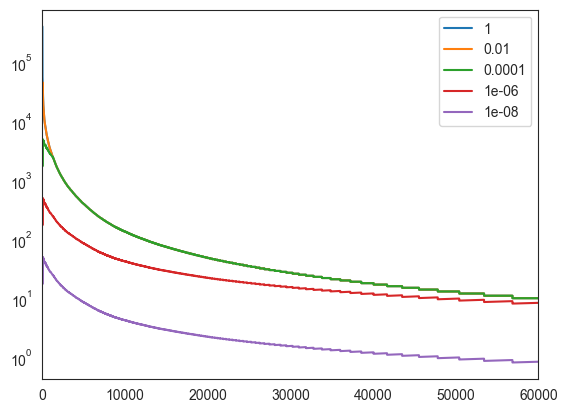

In [44]:
df = s['count'].to_frame('freq')
factors = [1, 1e-2, 1e-4, 1e-6, 1e-8]
for f in factors:
    sf = make_sampling_table(vocab_size, sampling_factor=f)
    df[f] = df.freq.mul(sf)
df.loc[:, factors].plot(logy=True, xlim=(0, 60000));

In [45]:
sampling_table = make_sampling_table(vocab_size, sampling_factor=SAMPLING_FACTOR/10)

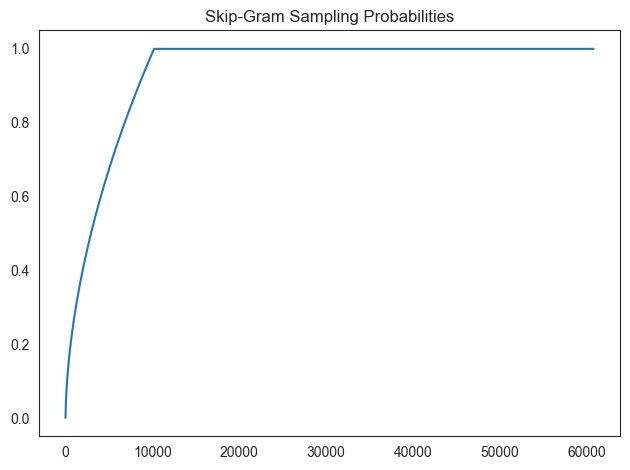

In [46]:
pd.Series(sampling_table).plot(title='Skip-Gram Sampling Probabilities')
plt.tight_layout();

### Generate target-context word pairs

This step converts the integer-encoded corpus into the actual training
examples that the skip-gram model will consume. Each example is a triple
`(target_id, context_id, label)` where the label tells the model whether
the pair is a genuine co-occurrence or a fabricated noise pair.

---

#### The sliding window mechanism

For every token at position $t$ in the sequence `data`, the algorithm
considers all tokens within a symmetric window of radius `WINDOW_SIZE`:

$$
\text{context positions} = \{t - k,\; \ldots,\; t - 1,\; t + 1,\; \ldots,\; t + k\}
\quad k = \texttt{WINDOW\_SIZE}
$$

Every (target, context) pair extracted this way is a **positive example**
(label `1`): these are words that genuinely co-occur in the corpus and
whose vectors the model should push closer together.

---

#### Negative sampling

For each positive pair the model also needs **negative examples** — pairs
of words that do *not* meaningfully co-occur — so that it has something to
push apart. The parameter `negative_samples=1.0` sets a **1 : 1 ratio**:
for every real pair one noise pair is generated by keeping the target word
and replacing the context word with a token drawn at random from the
vocabulary.

The full call is:

```python
pairs, labels = skipgrams(
    sequence         = data,
    vocabulary_size  = vocab_size,
    window_size      = WINDOW_SIZE,
    sampling_table   = sampling_table,
    negative_samples = 1.0,
    shuffle          = True
)
```

| Parameter | Role |
|---|---|
| `sequence` | The integer-encoded corpus (`data`) |
| `vocabulary_size` | Size of the vocabulary; sets the range for random negative sampling |
| `window_size` | Radius of the context window around each target |
| `sampling_table` | Per-word retention probabilities (built in §2.5); suppresses over-represented common words |
| `negative_samples` | Ratio of noise pairs to real pairs (1.0 = equal numbers) |
| `shuffle` | Randomises the order of all pairs before training |

---

#### Unpacking and memory layout

`skipgrams()` returns a Python list of `[target, context]` sublists and a
parallel list of integer labels. These are immediately converted to NumPy
arrays and transposed for efficient downstream access:

```python
target_word, context_word = np.array(pairs, dtype=np.int32).T
labels = np.array(labels, dtype=np.int8)
del pairs   # free the original list immediately
```

- `dtype=np.int32` for the word IDs — sufficient for vocabularies up to
  ~2 billion entries, half the memory of `int64`.
- `dtype=np.int8` for labels — only two values (0 and 1), so a single
  byte per element is enough; saves significant memory across millions
  of pairs.
- `del pairs` releases the original Python list as soon as the arrays
  are built, since holding both simultaneously would double peak memory.

After unpacking, inspecting the first few rows confirms the structure:

```python
df = pd.DataFrame({
    'target' : target_word[:5],
    'context': context_word[:5],
    'label'  : labels[:5]
})
```

And `pd.Series(labels).value_counts()` verifies that positive and
negative pairs are balanced at the expected 1 : 1 ratio.

---

#### Persistence to HDF5

Generating the pairs from scratch is the most time-consuming step in the
entire pipeline. To avoid repeating it on every run, all three arrays are
written to a single HDF5 file:

```python
with pd.HDFStore(results_path / 'data.h5') as store:
    store.put('id_to_token', pd.Series(id_to_token))
    store.put('pairs', pd.DataFrame({
        'target' : target_word,
        'context': context_word,
        'labels' : labels
    }))
```

On subsequent runs the file is reloaded in seconds:

```python
with pd.HDFStore(results_path / 'data.h5') as store:
    id_to_token = store['id_to_token']
    pairs       = store['pairs']
target_word, context_word, labels = pairs.target, pairs.context, pairs.labels
```

HDF5 is preferred over CSV here because it preserves the integer dtypes
exactly, supports columnar compression, and reads orders of magnitude
faster than a text format for arrays of this size.

---

#### What the model will see

After this step the training data is fully prepared. The Keras model
receives two integer arrays (`target_word`, `context_word`) as inputs and
one binary array (`labels`) as the supervision signal. A label of `1`
tells the model *"these two words co-occur — pull their vectors together"*;
a label of `0` tells it *"this pair is noise — push their vectors apart"*.
The tension between these two forces is what shapes the geometry of the
final embedding space.
```

In [47]:
pairs, labels = skipgrams(sequence=data,
                          vocabulary_size=vocab_size,
                          window_size=WINDOW_SIZE,
                          sampling_table=sampling_table,
                          negative_samples=1.0,
                          shuffle=True)

print('{:,d} pairs created'.format(len(pairs)))

65,137,576 pairs created


In [48]:
target_word, context_word = np.array(pairs, dtype=np.int32).T
labels = np.array(labels, dtype=np.int8)
del pairs

In [49]:
target_word[:5]

array([ 5842,  2647,  1036, 11246,  3767])

In [50]:
df = pd.DataFrame({'target': target_word[:5], 
                   'context': context_word[:5], 
                   'label': labels[:5]})
df

,target,context,label
0,5842,17636,0
1,2647,38257,0
2,1036,43962,0
3,11246,19370,0
4,3767,16864,0


In [52]:
pd.Series(labels).value_counts()

0    32568788
1    32568788
Name: count, dtype: int64

In [53]:
print(results_path)

C:\data\01-algo-trading\results\financial_news


In [54]:
with pd.HDFStore(results_path / 'data.h5') as store:
    store.put('id_to_token', pd.Series(id_to_token))
    store.put('pairs', pd.DataFrame({'target' : target_word,
                                     'context': context_word, 
                                     'labels': labels}))

In [55]:
with pd.HDFStore(results_path / 'data.h5') as store:
    id_to_token = store['id_to_token']
    pairs = store['pairs']
target_word, context_word, labels = pairs.target, pairs.context, pairs.labels

### Define Keras Model Components

The skip-gram model is assembled using the **Keras functional API**, which
makes every layer and connection explicit. The graph has two parallel input
branches that merge into a single binary output.

---

#### Inputs

Two scalar integer inputs carry the target and context word IDs respectively:

```python
input_target  = Input((1,), name='target_input')
input_context = Input((1,), name='context_input')
```

Each input is a single integer — the ID of one word — fed independently
into the shared embedding layer below.

---

#### Shared Embedding Layer

```python
embedding = Embedding(input_dim=vocab_size,
                      output_dim=EMBEDDING_SIZE,
                      input_length=1,
                      name='embedding_layer')
```

This is the only layer that holds **trainable parameters**: a weight matrix
of shape $(V \times d)$, where $V$ is the vocabulary size and $d = 300$ is
the embedding dimension. Both inputs pass through the **same** layer object,
so target and context words share a single set of vectors. After lookup, each
ID is replaced by its $d$-dimensional vector and immediately reshaped to
$(d \times 1)$ for the dot product step.

---

#### Similarity Measure

The dot product between the two embedding vectors measures how aligned they
are in the embedding space:

$$
\text{score}(w_t, w_c) = \mathbf{v}_{w_t}^\top \mathbf{v}_{w_c}
$$

```python
dot_product = Dot(axes=1)([target, context])
```

A high score means the model considers the two words likely to co-occur;
a low or negative score means they are unrelated. The result is reshaped
to a scalar `(1,)` before passing to the output layer.

---

#### Output Layer

A single sigmoid neuron squashes the dot product into a probability in
$[0, 1]$:

$$
\hat{y} = \sigma\!\left(\mathbf{v}_{w_t}^\top \mathbf{v}_{w_c}\right)
$$

```python
output = Dense(1, activation='sigmoid', name='output')(dot_product)
```

The model is compiled with **binary cross-entropy** loss and **RMSprop**
optimiser — appropriate choices given that the task is binary classification
(real pair vs. noise pair).

---

#### Validation Model

A second model is built on top of the **same layers and weights**, replacing
the raw dot product with a **cosine similarity** (`Dot(normalize=True)`):

```python
similarity      = Dot(normalize=True, axes=1)([target, context])
validation_model = Model(inputs=[input_target, input_context],
                         outputs=similarity)
```

Because it shares the embedding layer with the training model, its outputs
always reflect the current state of the learned vectors. It is never trained
directly — it is only called inside `EvalCallback` at the end of each epoch
to retrieve nearest neighbours and measure analogy accuracy, giving a
human-readable window into how the embedding space is evolving.
```

#### Scalar Input Variables

In [56]:
input_target = Input((1,), name='target_input')
input_context = Input((1,), name='context_input')

#### Shared Embedding Layer

In [57]:
embedding = Embedding(input_dim=vocab_size,
                      output_dim=EMBEDDING_SIZE,
                      input_length=1,
                      name='embedding_layer')

C:\Users\User\anaconda3\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [59]:
target = embedding(input_target)
target = Reshape((EMBEDDING_SIZE, 1), name='target_embedding')(target)

context = embedding(input_context)
context = Reshape((EMBEDDING_SIZE, 1), name='context_embedding')(context)

#### Create Similarity Measure

In [60]:
dot_product = Dot(axes=1)([target, context])
dot_product = Reshape((1,), name='similarity')(dot_product)

#### Sigmoid Output Layer

In [61]:
output = Dense(units=1, activation='sigmoid', name='output')(dot_product)

#### Compile Training Model

In [62]:
model = Model(inputs=[input_target, input_context], outputs=output)
model.compile(loss='binary_crossentropy', optimizer='rmsprop')

#### Display Architecture

In [63]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ target_input (InputLayer)     │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ context_input (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_layer (Embedding)   │ (None, 1, 300)            │      18,246,600 │ target_input[0][0],        │
│                               │                           │                 │ context_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ target_embedding (Reshape)    │ (None, 300, 1)            │               0 │ embedding_layer[2][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ context_embedding (Reshape)   │ (None, 300, 1)            │               0 │ embedding_layer[3][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dot (Dot)                     │ (None, 1, 1)              │               0 │ target_embedding[0][0],    │
│                               │                           │                 │ context_embedding[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ similarity (Reshape)          │ (None, 1)                 │               0 │ dot[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 1)                 │               2 │ similarity[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 18,246,602 (69.61 MB)

 Trainable params: 18,246,602 (69.61 MB)

 Non-trainable params: 0 (0.00 B)

#### Validation Model

In [64]:
similarity = Dot(normalize=True, 
                 axes=1, 
                 name='cosine_similarity')([target, context])

In [65]:
# create a secondary validation model to run our similarity checks during training
validation_model = Model(inputs=[input_target, input_context], outputs=similarity)

In [66]:
validation_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ target_input (InputLayer)     │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ context_input (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_layer (Embedding)   │ (None, 1, 300)            │      18,246,600 │ target_input[0][0],        │
│                               │                           │                 │ context_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ target_embedding (Reshape)    │ (None, 300, 1)            │               0 │ embedding_layer[2][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ context_embedding (Reshape)   │ (None, 300, 1)            │               0 │ embedding_layer[3][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cosine_similarity (Dot)       │ (None, 1, 1)              │               0 │ target_embedding[0][0],    │
│                               │                           │                 │ context_embedding[0][0]    │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 18,246,600 (69.61 MB)

 Trainable params: 18,246,600 (69.61 MB)

 Non-trainable params: 0 (0.00 B)

### Create Keras Callbacks

####  Nearest Neighors & Analogies

In [67]:
test_set = analogies_id.dropna().astype(int)
a, b, c, actual = test_set.values.T
actual = actual.reshape(-1, 1)
n_analogies = len(actual)

In [68]:
class EvalCallback(Callback):
        
    def on_train_begin(self, logs={}):
        self.eval_nn()
        self.test_analogies()

    def on_train_end(self, logs={}):
        self.eval_nn()

    def on_epoch_end(self, batch, logs={}):
        self.test_analogies()

    @staticmethod
    def test_analogies():
        print('\nAnalogy Accuracy:\n\t', end='')
        embeddings = embedding.get_weights()[0]
        target = embeddings[c] + embeddings[b] - embeddings[a]
        neighbors = np.argsort(cdist(target, embeddings, metric='cosine'))
        match_id = np.argwhere(neighbors == actual)[:, 1]
        print('\n\t'.join(['Top {}: {:.2%}'.format(i, (match_id < i).sum() / n_analogies) for i in [1, 5, 10]]))

    def eval_nn(self):
        print('\n{} Nearest Neighbors:'.format(NN))
        for i in range(VALID_SET):
            valid_id = valid_examples[i]
            valid_word = id_to_token[valid_id]
            similarity = self._get_similiarity(valid_id).reshape(-1)
            nearest = (-similarity).argsort()[1:NN + 1]
            neighbors = [id_to_token[nearest[n]] for n in range(NN)]
            print('{}:\t{}'.format(valid_word, ', '.join(neighbors)))            
        
    @staticmethod
    def _get_similiarity(valid_word_idx):
        target = np.full(shape=vocab_size, fill_value=valid_word_idx)
        context = np.arange(vocab_size)
        return validation_model.predict([target, context])


evaluation = EvalCallback()

#### Tensorboard Callback

Currently tensorflow has a [bug](https://github.com/tensorflow/tensorflow/issues/32902) that prevents metadata from working. The GitHub issue points to a simple fix that you can apply to the tensorflow source code, just search for the culprit line and change accordingly until a later release remedies this problem. You will have to install with `pip` for this purpose.

In [69]:
tensorboard = TensorBoard(log_dir=str(tb_path),
                          write_graph=True,
                          embeddings_freq=1,
                          embeddings_metadata={'embedding_layer': 
                                               str(tb_path / 'meta.tsv')})

### Train Model

In [70]:
loss = model.fit(x=[target_word, context_word],
                 y=labels,
                 shuffle=True,
                 batch_size=BATCH_SIZE,
                 epochs=EPOCHS,
#                  callbacks=[evaluation, tensorboard] # uncomment if tensorboard bug is fixed
                 callbacks=[evaluation]
                )


10 Nearest Neighbors:
   1/1901 ━━━━━━━━━━━━━━━━━━━━ 9:37 304ms/step

C:\Users\User\anaconda3\lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['target_input', 'context_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(


1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
development:	capella, bernie, integrated_real_estate, caixin, charges, comply, reporting_jon_herskovitz, ose_immunotherapeutics, chennai, poseida
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
gaap:	lodging_real_estate, councils, sceptics, tonnage_grade_reference, lawson, kevin_brady, reporting_conor_humphries, prolific, environmentally_responsible_manner, woman
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
shares:	fierce_debate, kps, pragmatist, threatened_withdraw, michal, height_cold, brown_brown, onslaught_eastern_ghouta, innophos, finder
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
release:	residency, bridgestone, files, swing, ai_powered, nationalized, brt_apartments, dispute_resolution, cad, description_risks_uncertainties
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
result:	turing, ihs_markit, economist_mufg, unicorns, ojea_quintana, investview, amundi_pioneer, petcare, prolonged_stalemate, valves
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
high:	

In [71]:
model.save(str(results_path / 'skipgram_model.h5'))

### Visualize Embeddings using Tensorboard

Load the embeddings metadata using the `load` option to view embedding labels and see [tutorial](https://www.tensorflow.org/tensorboard/get_started) for usage instructions.

In [72]:
%load_ext tensorboard

In [73]:
%tensorboard --logdir results/financial_news/tensorboard/train

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\User\anaconda3\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\User\anaconda3\Scripts\tensorboard.exe\__main__.py", line 4, in <module>
  File "C:\Users\User\anaconda3\lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\User\anaconda3\lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

## Resources

- [Distributed representations of words and phrases and their compositionality](http://papers.nips.cc/paper/5021-distributed-representations-of-words-and-phrases-and-their-compositionality.pdf)
- [Efficient estimation of word representations in vector space](https://arxiv.org/pdf/1301.3781.pdf?)
- [Sebastian Ruder's Blog](http://ruder.io/word-embeddings-1/)